# HW2 Digit Enhance (Clean)

Digit MNIST experiments with HOG features, augmentation, and model improvements.

In [18]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from skimage.feature import hog

In [19]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [20]:
# Data loading
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('Digit MNIST loaded:', X_train.shape, y_train.shape)

Digit MNIST loaded: (60000, 28, 28) (60000,)


In [21]:
def describe_raw(name, X, y):
    print(f'{name}')
    print(f'  X shape: {X.shape}, dtype: {X.dtype}')
    print(f'  y shape: {y.shape}, dtype: {y.dtype}')
    print(f'  X min/max: {X.min()} / {X.max()}')
    print(f'  Unique labels: {np.unique(y)}')

describe_raw('Digit MNIST (raw)', X_train, y_train)

Digit MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [22]:
def show_samples(title, images, labels=None, n=8, cmap='gray'):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2, 2.5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if labels is not None:
            plt.title(str(labels[i]))
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Feature Engineering 1: HOG

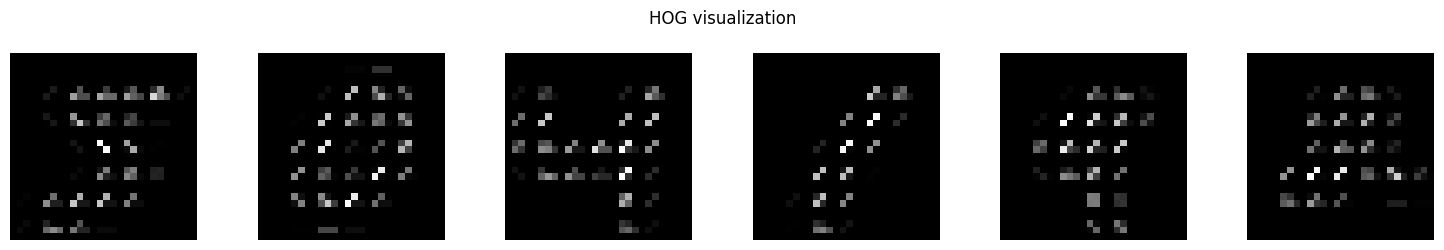

In [23]:
def extract_hog_features(images):
    images = images.reshape(-1, 28, 28)
    win_size = images[0].shape
    cell_size = (4, 4)
    block_size = (8, 8)
    block_stride = (4, 4)
    num_bins = 9
    hog_desc = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)
    num_images = images.shape[0]
    feat_size = len(hog_desc.compute(images[0].astype(np.uint8)))
    feats = np.zeros((num_images, feat_size), dtype=np.float32)
    for i, img in enumerate(images):
        feats[i] = hog_desc.compute(img.astype(np.uint8)).flatten()
    return feats

def show_hog_visuals(images, n=6):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2.5, 2.5))
    for i in range(n):
        _, hog_image = hog(images[i], orientations=9, pixels_per_cell=(4, 4),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
        plt.subplot(1, n, i + 1)
        plt.imshow(hog_image, cmap='gray')
        plt.axis('off')
    plt.suptitle('HOG visualization')
    plt.tight_layout()
    plt.show()

show_hog_visuals(X_train[:6])

In [24]:
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

## Model + Training

In [25]:
class BaselineANN(nn.Module):
    def __init__(self, input_size, hidden_size=512, output_size=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 128)
        self.fc4 = nn.Linear(128, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

In [26]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)
        preds = model(X)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(preds, 1)
        acc = (predicted == y).sum().item() / len(y)
        total_loss += loss.item()
        total_acc += acc
        num_batches += 1
    return total_loss / num_batches, total_acc / num_batches

def train_model(model, dataloader, epochs=20, lr=0.001, save_best=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_loss = float('inf')
    for epoch in range(epochs):
        loss, acc = train_epoch(model, dataloader, optimizer, criterion)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}, Acc: {acc:.4f}')
        if save_best and loss < best_loss:
            best_loss = loss
            torch.save(copy.deepcopy(model.state_dict()), save_best)
    return model

def evaluate_model(model, X_test, y_test, num_classes=10):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
        labels = torch.tensor(y_test).to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        pred_cpu = predicted.cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        accuracy = (pred_cpu == labels_cpu).mean()
        f1 = f1_score(labels_cpu, pred_cpu, average='weighted')
        precision = precision_score(labels_cpu, pred_cpu, average='weighted')
        recall = recall_score(labels_cpu, pred_cpu, average='weighted')
        cm = confusion_matrix(labels_cpu, pred_cpu)
        print(f'Accuracy: {accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        return accuracy, f1, precision, recall, cm

Epoch 1/30 - Loss: 1.7038, Acc: 0.7003
Epoch 2/30 - Loss: 0.2737, Acc: 0.9306
Epoch 3/30 - Loss: 0.1292, Acc: 0.9605
Epoch 4/30 - Loss: 0.0944, Acc: 0.9710
Epoch 5/30 - Loss: 0.0748, Acc: 0.9764
Epoch 6/30 - Loss: 0.0632, Acc: 0.9795
Epoch 7/30 - Loss: 0.0563, Acc: 0.9822
Epoch 8/30 - Loss: 0.0507, Acc: 0.9842
Epoch 9/30 - Loss: 0.0454, Acc: 0.9856
Epoch 10/30 - Loss: 0.0410, Acc: 0.9874
Epoch 11/30 - Loss: 0.0377, Acc: 0.9888
Epoch 12/30 - Loss: 0.0353, Acc: 0.9891
Epoch 13/30 - Loss: 0.0328, Acc: 0.9902
Epoch 14/30 - Loss: 0.0318, Acc: 0.9906
Epoch 15/30 - Loss: 0.0290, Acc: 0.9914
Epoch 16/30 - Loss: 0.0250, Acc: 0.9928
Epoch 17/30 - Loss: 0.0246, Acc: 0.9927
Epoch 18/30 - Loss: 0.0239, Acc: 0.9930
Epoch 19/30 - Loss: 0.0231, Acc: 0.9932
Epoch 20/30 - Loss: 0.0198, Acc: 0.9944
Epoch 21/30 - Loss: 0.0181, Acc: 0.9950
Epoch 22/30 - Loss: 0.0171, Acc: 0.9953
Epoch 23/30 - Loss: 0.0161, Acc: 0.9956
Epoch 24/30 - Loss: 0.0139, Acc: 0.9964
Epoch 25/30 - Loss: 0.0128, Acc: 0.9968
Epoch 26/

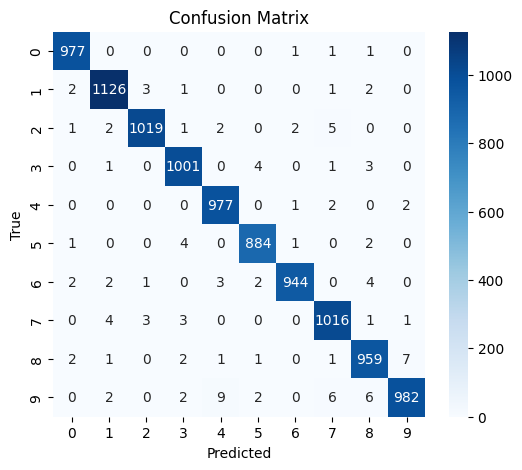

(np.float64(0.9885),
 0.9884943865256173,
 0.9885185082943657,
 0.9885,
 array([[ 977,    0,    0,    0,    0,    0,    1,    1,    1,    0],
        [   2, 1126,    3,    1,    0,    0,    0,    1,    2,    0],
        [   1,    2, 1019,    1,    2,    0,    2,    5,    0,    0],
        [   0,    1,    0, 1001,    0,    4,    0,    1,    3,    0],
        [   0,    0,    0,    0,  977,    0,    1,    2,    0,    2],
        [   1,    0,    0,    4,    0,  884,    1,    0,    2,    0],
        [   2,    2,    1,    0,    3,    2,  944,    0,    4,    0],
        [   0,    4,    3,    3,    0,    0,    0, 1016,    1,    1],
        [   2,    1,    0,    2,    1,    1,    0,    1,  959,    7],
        [   0,    2,    0,    2,    9,    2,    0,    6,    6,  982]]))

In [27]:
hog_loader = DataLoader(list(zip(torch.tensor(X_train_hog, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))),
                        batch_size=4096, shuffle=True, num_workers=2)
hog_model = BaselineANN(input_size=X_train_hog.shape[1]).to(device)
train_model(hog_model, hog_loader, epochs=30, lr=0.001, save_best='best_digit_hog.pth')
evaluate_model(hog_model, X_test_hog, y_test, num_classes=10)

## Feature Engineering 2: Data Augmentation (HOG from augmented images)

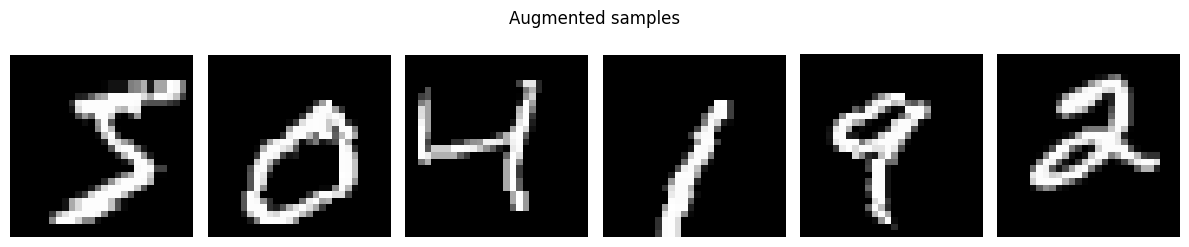

In [28]:
class HOGAugDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        if len(data.shape) == 2:
            self.data = data.reshape(-1, 28, 28).astype(np.uint8)
        else:
            self.data = data.astype(np.uint8)
        self.labels = labels
        self.transform = transform
        win_size = (28, 28)
        cell_size = (4, 4)
        block_size = (8, 8)
        block_stride = (4, 4)
        num_bins = 9
        self.hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.data[idx]
        if self.transform:
            image = self.transform(transforms.ToPILImage()(image))
            image = np.array(image, dtype=np.uint8)
        hog_feat = self.hog.compute(image).flatten()
        return torch.tensor(hog_feat, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
])

aug_dataset = HOGAugDataset(X_train, y_train, transform=aug_transform)
aug_loader = DataLoader(aug_dataset, batch_size=4096, shuffle=True, num_workers=2)

# Plot augmented examples
aug_images = []
for i in range(6):
    img = np.array(aug_transform(transforms.ToPILImage()(X_train[i])), dtype=np.uint8)
    aug_images.append(img)
show_samples('Augmented samples', np.array(aug_images))

Epoch 1/20 - Loss: 1.8396, Acc: 0.5311
Epoch 2/20 - Loss: 0.6362, Acc: 0.7987
Epoch 3/20 - Loss: 0.4125, Acc: 0.8657
Epoch 4/20 - Loss: 0.3224, Acc: 0.8999
Epoch 5/20 - Loss: 0.2765, Acc: 0.9130
Epoch 6/20 - Loss: 0.2459, Acc: 0.9232
Epoch 7/20 - Loss: 0.2269, Acc: 0.9294
Epoch 8/20 - Loss: 0.2082, Acc: 0.9358
Epoch 9/20 - Loss: 0.1915, Acc: 0.9406
Epoch 10/20 - Loss: 0.1785, Acc: 0.9440
Epoch 11/20 - Loss: 0.1700, Acc: 0.9460
Epoch 12/20 - Loss: 0.1561, Acc: 0.9526
Epoch 13/20 - Loss: 0.1466, Acc: 0.9545
Epoch 14/20 - Loss: 0.1362, Acc: 0.9576
Epoch 15/20 - Loss: 0.1312, Acc: 0.9593
Epoch 16/20 - Loss: 0.1244, Acc: 0.9601
Epoch 17/20 - Loss: 0.1189, Acc: 0.9624
Epoch 18/20 - Loss: 0.1121, Acc: 0.9647
Epoch 19/20 - Loss: 0.1072, Acc: 0.9666
Epoch 20/20 - Loss: 0.1030, Acc: 0.9679
Accuracy: 0.9876
F1 Score: 0.9876
Precision: 0.9876
Recall: 0.9876


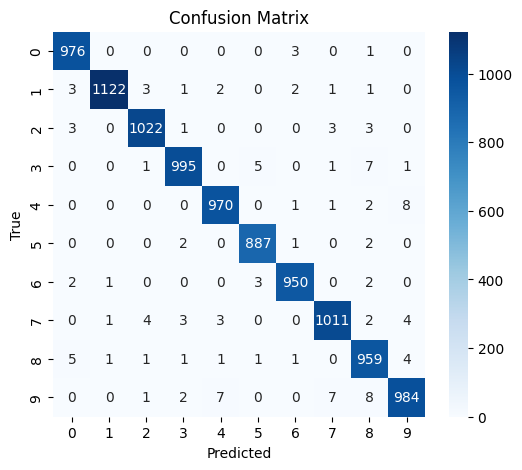

(np.float64(0.9876),
 0.9876024165353982,
 0.9876277435737791,
 0.9876,
 array([[ 976,    0,    0,    0,    0,    0,    3,    0,    1,    0],
        [   3, 1122,    3,    1,    2,    0,    2,    1,    1,    0],
        [   3,    0, 1022,    1,    0,    0,    0,    3,    3,    0],
        [   0,    0,    1,  995,    0,    5,    0,    1,    7,    1],
        [   0,    0,    0,    0,  970,    0,    1,    1,    2,    8],
        [   0,    0,    0,    2,    0,  887,    1,    0,    2,    0],
        [   2,    1,    0,    0,    0,    3,  950,    0,    2,    0],
        [   0,    1,    4,    3,    3,    0,    0, 1011,    2,    4],
        [   5,    1,    1,    1,    1,    1,    1,    0,  959,    4],
        [   0,    0,    1,    2,    7,    0,    0,    7,    8,  984]]))

In [30]:
aug_model = BaselineANN(input_size=X_train_hog.shape[1]).to(device)
train_model(aug_model, aug_loader, epochs=20, lr=0.001, save_best='best_digit_aug.pth')
evaluate_model(aug_model, X_test_hog, y_test, num_classes=10)

## Model Improvements (BatchNorm + Dropout)

Epoch 1/40 - Loss: 0.6018, Acc: 0.8199
Epoch 2/40 - Loss: 0.1609, Acc: 0.9490
Epoch 3/40 - Loss: 0.1090, Acc: 0.9648
Epoch 4/40 - Loss: 0.0872, Acc: 0.9723
Epoch 5/40 - Loss: 0.0762, Acc: 0.9754
Epoch 6/40 - Loss: 0.0701, Acc: 0.9772
Epoch 7/40 - Loss: 0.0655, Acc: 0.9788
Epoch 8/40 - Loss: 0.0593, Acc: 0.9810
Epoch 9/40 - Loss: 0.0542, Acc: 0.9825
Epoch 10/40 - Loss: 0.0515, Acc: 0.9832
Epoch 11/40 - Loss: 0.0524, Acc: 0.9832
Epoch 12/40 - Loss: 0.0487, Acc: 0.9842
Epoch 13/40 - Loss: 0.0499, Acc: 0.9840
Epoch 14/40 - Loss: 0.0451, Acc: 0.9849
Epoch 15/40 - Loss: 0.0439, Acc: 0.9860
Epoch 16/40 - Loss: 0.0427, Acc: 0.9865
Epoch 17/40 - Loss: 0.0425, Acc: 0.9859
Epoch 18/40 - Loss: 0.0415, Acc: 0.9865
Epoch 19/40 - Loss: 0.0402, Acc: 0.9867
Epoch 20/40 - Loss: 0.0375, Acc: 0.9868
Epoch 21/40 - Loss: 0.0364, Acc: 0.9880
Epoch 22/40 - Loss: 0.0371, Acc: 0.9878
Epoch 23/40 - Loss: 0.0354, Acc: 0.9884
Epoch 24/40 - Loss: 0.0339, Acc: 0.9887
Epoch 25/40 - Loss: 0.0333, Acc: 0.9893
Epoch 26/

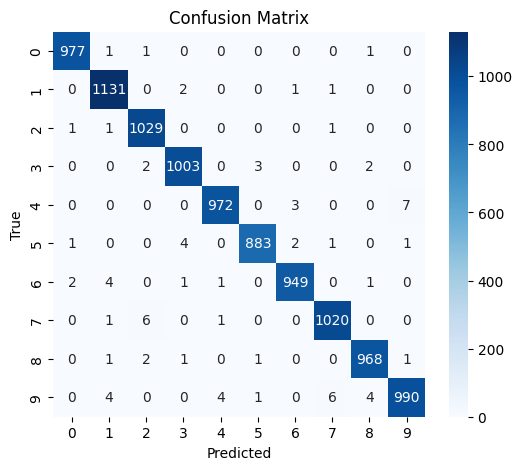

(np.float64(0.9922),
 0.9921958389789268,
 0.9922049734456219,
 0.9922,
 array([[ 977,    1,    1,    0,    0,    0,    0,    0,    1,    0],
        [   0, 1131,    0,    2,    0,    0,    1,    1,    0,    0],
        [   1,    1, 1029,    0,    0,    0,    0,    1,    0,    0],
        [   0,    0,    2, 1003,    0,    3,    0,    0,    2,    0],
        [   0,    0,    0,    0,  972,    0,    3,    0,    0,    7],
        [   1,    0,    0,    4,    0,  883,    2,    1,    0,    1],
        [   2,    4,    0,    1,    1,    0,  949,    0,    1,    0],
        [   0,    1,    6,    0,    1,    0,    0, 1020,    0,    0],
        [   0,    1,    2,    1,    0,    1,    0,    0,  968,    1],
        [   0,    4,    0,    0,    4,    1,    0,    6,    4,  990]]))

In [31]:
class ANNWithBN(nn.Module):
    def __init__(self, input_size, hidden_size=512, output_size=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, output_size)
        # self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

bn_do_model = ANNWithBN(input_size=X_train_hog.shape[1]).to(device)
train_model(bn_do_model, aug_loader, epochs=40, lr=0.01, save_best='best_digit_bn_do.pth')
evaluate_model(bn_do_model, X_test_hog, y_test, num_classes=10)

Total misclassified samples: 115


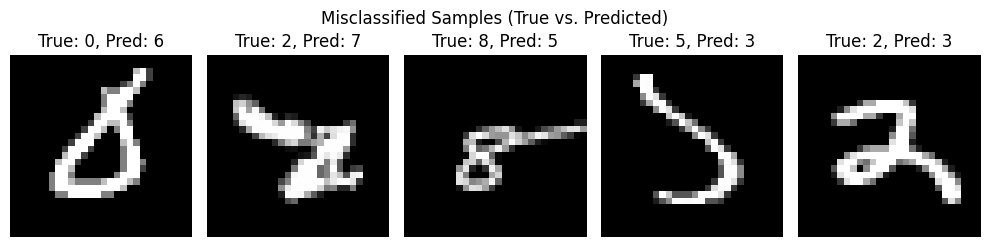

In [39]:
best_model_path = 'best_digit_hog.pth'
best_model = BaselineANN(input_size=X_train_hog.shape[1]).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

with torch.no_grad():
    inputs = torch.tensor(X_test_hog, dtype=torch.float32).to(device)
    labels = torch.tensor(y_test).to(device)
    outputs = best_model(inputs)
    _, predicted = torch.max(outputs, 1)

pred_cpu = predicted.cpu().numpy()
labels_cpu = labels.cpu().numpy()

misclassified_indices = np.where(pred_cpu != labels_cpu)[0]

print(f"Total misclassified samples: {len(misclassified_indices)}")

# Select a few misclassified samples to display
num_samples_to_show = 5
sample_indices = np.random.choice(misclassified_indices, num_samples_to_show, replace=False)

misclassified_images = X_test[sample_indices]
misclassified_true_labels = labels_cpu[sample_indices]
misclassified_predicted_labels = pred_cpu[sample_indices]

display_labels = [f'True: {t}, Pred: {p}' for t, p in zip(misclassified_true_labels, misclassified_predicted_labels)]

show_samples('Misclassified Samples (True vs. Predicted)', misclassified_images, labels=display_labels, n=num_samples_to_show)

## Notes

- Record metrics for HOG, augmented HOG, and BN+Dropout variants.
- Include confusion matrices for the final model in the report.